In [2]:
from gerrychain import Graph
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain, proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.tree import recursive_tree_part, bipartition_tree, find_balanced_edge_cuts_memoization
from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias
from gerrychain.updaters import cut_edges

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

from functools import partial
import numpy as np
import csv
import pandas as pd

In [3]:
graph = Graph.from_json("./GA_Processed/output/GA_Processed_Precincts.json")
df = gpd.read_file("./GA_Processed/output/GA_Processed_Precincts.shp")

In [5]:
df.keys()

Index(['PRECINCTID', 'population', 'populati_1', 'G20PRERTRU', 'G20PREDBID',
       'G20USSRPER', 'G20USSDOSS', 'Total', 'Hispanic', 'NH_White', 'NH_Black',
       'NH_Other', 'Total_VAP', 'Hispanic_V', 'NH_White_V', 'NH_Black_V',
       'NH_Other_V', 'COUNTYFP', 'CON', 'SLDU', 'SLDL', 'C_X', 'C_Y',
       'geometry'],
      dtype='object')

In [4]:
def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    df["current"] = df["PRECINCTID"].map(partition.assignment)

    counties = sum(df.groupby("COUNTYFP")['current'].nunique()>1)
    return counties

election_names = [
    "PRE",
    "USS"
]

num_elections = len(election_names)

election_columns = [
  ['G20PRERTRU','G20PREDBID'],
  ['G20USSRPER','G20USSDOSS']
]

my_updaters = {
    "population": updaters.Tally("population", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_NH_Black"] = graph.nodes()[node]["population"] - graph.nodes()[node]["NH_Black"]

my_updaters.update({"NH_Black":Election("NH_Black",{"NH_Black": "NH_Black", "non_NH_Black": "non_NH_Black"})})
my_updaters.update()

# save percentages

my_updaters.update(election_updaters)


In [5]:
ideal_population = df['population'].sum() / 14 # number of congressional districts
cd_dict = recursive_tree_part(graph, range(14), ideal_population, "population",.02)
tree_partition = GeographicPartition(graph, cd_dict, my_updaters)

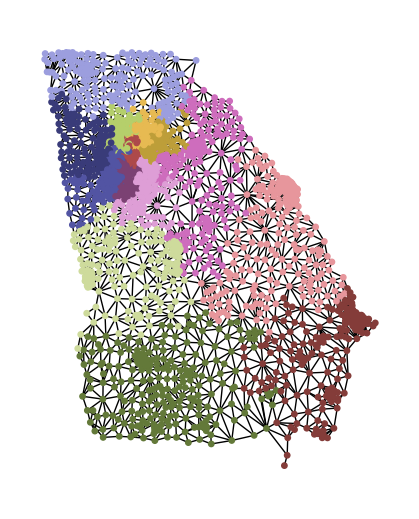

In [40]:
plt.figure(figsize=(4,5))
nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)

In [6]:
# w/ new county surcharge that weights edges of counties more

county_proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    region_surcharge = {"COUNTYFP":0.57}, #adds weight of one to the county edges
    method=partial(bipartition_tree,max_attempts=1000,warn_attempts=1000,allow_pair_reselection=True)
)

second_recom_chain = MarkovChain(
    proposal=county_proposal,
    constraints=[],
    accept=accept.always_accept,
    initial_state=tree_partition,
    total_steps=1000
)

In [42]:
i = 0
for part in second_recom_chain:
    if i%100 == 0:
        print(i)
    if part['county_splits'] < 19:
        break 
    i=i+1


0


In [43]:
part['county_splits']

18

In [9]:
import json

In [ ]:


ad = dict(part.assignment)

with open("./GA_Seed_Plans/ga_seed_plan5.json", "w") as file:
    json.dump(ad,file)

In [7]:
CONPart = GeographicPartition(graph, "CON", my_updaters)

In [10]:
ads = []
for i in range(1,6):
    with open(f"./GA_Seed_Plans/ga_seed_plan{i}.json","r") as file:
        ads.append(json.load(file))

In [11]:
# constraints
# Relevant NC metrics: Equal number of representatives (+/- 5% of ideal population)

def county_constraint(partition):
    return partition['county_splits'] < 19

In [12]:
seeds = [CONPart, GeographicPartition(graph, ads[0],my_updaters),GeographicPartition(graph, ads[1],my_updaters),GeographicPartition(graph, ads[2],my_updaters),GeographicPartition(graph, ads[3],my_updaters),GeographicPartition(graph, ads[4],my_updaters)]

In [13]:
for seed in range(5,len(seeds)):
    second_recom_chain = MarkovChain(
        proposal = county_proposal,
        constraints=[county_constraint],
        accept=accept.always_accept,
        initial_state=seeds[seed],
        total_steps=100000
    )

    cs = [] # county splits
    mms = [] # mean median
    egs = [] # efficiency gap
    pbs = [] # partisan bias
    dvp = [] # dem voting perc
    pps = [] # polsby popper
    bvp = [] # black voting percent
    mbvp = [] # max black voting percent
    wins = [] # dem wins

    temp = 0
    for part in second_recom_chain:
        temp += 1

        if temp%1000 == 0:
            print(f"seed: {seed} temp: {temp}")
            ad = dict(part.assignment)

            with open("GA_assignment_current.json", "w") as file:
                json.dump(ad,file)

            plt.figure(figsize=(4,5))
            nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
            plt.savefig(f'./GA_Ensemble_Graphs/network_plot_seed{seed}_step{temp}.png')
            plt.close()

            df['current'] = df['PRECINCTID'].map(ad)
            df.plot(column='current', cmap='tab20b')
            plt.axis('off')
            plt.savefig(f'./GA_Ensemble_Graphs/df_plot_seed{seed}_step{temp}.png')
            plt.close()

            ndf = pd.DataFrame({"County splits":cs, "MM": mms, "EG": egs, "PB": pbs, "DWins": wins, "PP": pps})
            ndf.to_csv(f"./GA_Ensemble_Stats/chain_outputs_{seed}_{temp}.csv")

            with open(f"./GA_Ensemble_Stats/DemPercs_{seed}_{temp}.csv","w") as tf1:
                writer = csv.writer(tf1, lineterminator="\n")
                writer.writerows(dvp)

            with open(f"./GA_Ensemble_Stats/BlackPercs_{seed}_{temp}.csv","w") as tf1:
                writer = csv.writer(tf1, lineterminator="\n")
                writer.writerows(bvp)

            cs = [] # county splits
            mms = [] # mean median
            egs = [] # efficiency gap
            pbs = [] # partisan bias
            dvp = [] # dem voting perc
            pps = [] # polsby popper
            bvp = [] # black voting percent
            mbvp = [] # max black voting percent
            wins = [] # dem wins

        cs.append(part['county_splits'])
        mms.append(mean_median(part['PRE']))
        egs.append(efficiency_gap(part['PRE']))
        pbs.append(partisan_bias(part['PRE']))
        dvp.append(sorted(part['PRE'].percents("Democratic")))
        pps.append(sum([1/x for x in polsby_popper(part).values()])/14)
        bvp.append(sorted(part['NH_Black'].percents("NH_Black")))
        mbvp.append(max(bvp[-1]))
        wins.append(part['PRE'].wins("Democratic"))            

seed: 5 temp: 1000
seed: 5 temp: 2000
seed: 5 temp: 3000
seed: 5 temp: 4000
seed: 5 temp: 5000
seed: 5 temp: 6000
seed: 5 temp: 7000
seed: 5 temp: 8000
seed: 5 temp: 9000
seed: 5 temp: 10000
seed: 5 temp: 11000
seed: 5 temp: 12000
seed: 5 temp: 13000
seed: 5 temp: 14000
seed: 5 temp: 15000
seed: 5 temp: 16000
seed: 5 temp: 17000
seed: 5 temp: 18000
seed: 5 temp: 19000
seed: 5 temp: 20000
seed: 5 temp: 21000
seed: 5 temp: 22000
seed: 5 temp: 23000
seed: 5 temp: 24000
seed: 5 temp: 25000
seed: 5 temp: 26000
seed: 5 temp: 27000
seed: 5 temp: 28000
seed: 5 temp: 29000
seed: 5 temp: 30000
seed: 5 temp: 31000
seed: 5 temp: 32000
seed: 5 temp: 33000
seed: 5 temp: 34000
seed: 5 temp: 35000
seed: 5 temp: 36000
seed: 5 temp: 37000
seed: 5 temp: 38000
seed: 5 temp: 39000
seed: 5 temp: 40000
seed: 5 temp: 41000
seed: 5 temp: 42000
seed: 5 temp: 43000
seed: 5 temp: 44000
seed: 5 temp: 45000
seed: 5 temp: 46000
seed: 5 temp: 47000
seed: 5 temp: 48000
seed: 5 temp: 49000
seed: 5 temp: 50000
seed: 5 t